In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde

from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostRegressor

In [2]:
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.linewidth": 1.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False
})

sns.set_style("white")

In [3]:
wheat = pd.read_excel('../../dataset/nature data/wheat set.xlsx',sheet_name='Sheet1')
maize = pd.read_excel('../../dataset/nature data/maize set.xlsx')

In [5]:
print(wheat.shape,maize.shape)

(340, 54) (241, 54)


In [4]:
for df in [wheat, maize]:

    df['logIpc'] = np.log10(df['Ipc'] + 1e-9)
    df['logSRC'] = np.log10(df['Soil residual concentration'] + 1e-9)
    df['logED'] = np.log10(df['ED'] + 1e-9)

In [5]:
keep_cols =['Longitude','Latitude','PFAS']
wheat_keep = wheat[keep_cols].copy()
maize_keep = maize[keep_cols].copy()

In [6]:
drop_cols = [
    'Reference',
    'Sample',
    'Soil source',
    'PFAS',
    'Species',
    'Plant class',
    'Ipc',
    'BCF',
    'ED',
    'Soil residual concentration',
    'Longitude','Latitude'
]

wheat.drop(columns=drop_cols, inplace=True, errors='ignore')
maize.drop(columns=drop_cols, inplace=True, errors='ignore')

In [7]:
X_wheat = wheat.drop(columns=['lnBCF'], errors='ignore').copy()
y_wheat = wheat['lnBCF'].copy()

X_maize = maize.drop(columns=['lnBCF'], errors='ignore').copy()
y_maize = maize['lnBCF'].copy()

In [18]:
# cat_cols = [
#     'Tissue',
#     'Family','Genus','Order','monocot','woody','herb','crop','vegetable','legume','grass','perennial','edible'
# ]
# cat_cols = [c for c in cat_cols if c in X_wheat.columns] 

In [8]:
# ==========================================================
# Load universal CatBoost model
# ==========================================================

model = CatBoostRegressor()
model.load_model("../model/catboost_final.cbm")

In [9]:
model = CatBoostRegressor()
model.load_model("../model/catboost_final.cbm")
pred_wheat = model.predict(X_wheat)
pred_maize = model.predict(X_maize)

In [10]:
# ==========================================================
# Base predictions (0-shot)
# ==========================================================

pred_wheat = model.predict(X_wheat)
pred_maize = model.predict(X_maize)


In [11]:
# ==========================================================
# Evaluation
# ==========================================================

def evaluate(y_true, y_pred):

    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


In [12]:
# ==========================================================
# External validation
# ==========================================================

res_wheat = evaluate(y_wheat, pred_wheat)
res_maize = evaluate(y_maize, pred_maize)

external_df = pd.DataFrame([
    ["Wheat_Field", res_wheat["R2"], res_wheat["RMSE"], res_wheat["MAE"]],
    ["Maize_Field", res_maize["R2"], res_maize["RMSE"], res_maize["MAE"]],
], columns=["Dataset", "R2", "RMSE", "MAE"])

print("\n=== External Validation ===")
print(external_df)


=== External Validation ===
       Dataset        R2      RMSE       MAE
0  Wheat_Field -0.449565  2.262875  1.872361
1  Maize_Field  0.352434  2.059241  1.600363


In [13]:
def density_scatter(y_true, y_pred, save_path=None):

    x = np.array(y_true)
    y = np.array(y_pred)

    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    fig, ax = plt.subplots(figsize=(6,6))

    sc = ax.scatter(
        x,
        y,
        c=z,
        s=70,
        edgecolor='none'
    )

    lims = [
        min(x.min(), y.min()),
        max(x.max(), y.max())
    ]

    ax.plot(lims, lims, '--', linewidth=2)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    ax.text(
        0.05,
        0.95,
        f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}",
        transform=ax.transAxes,
        verticalalignment='top'
    )

    ax.set_xlabel("Observed lnBCF")
    ax.set_ylabel("Predicted lnBCF")
    #ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=600,
            bbox_inches='tight'
        )

    plt.show()

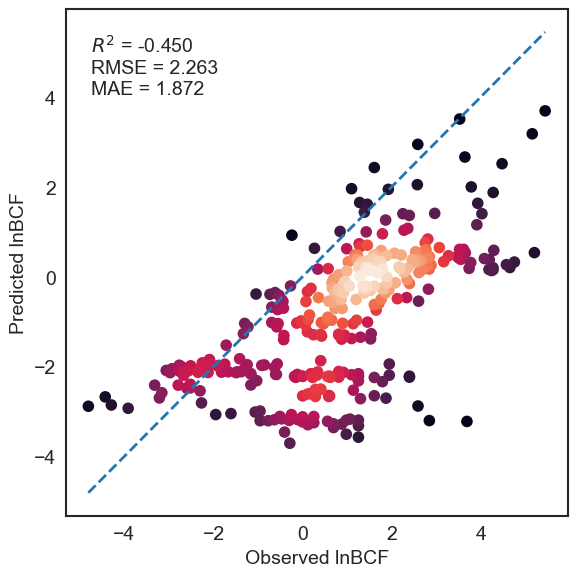

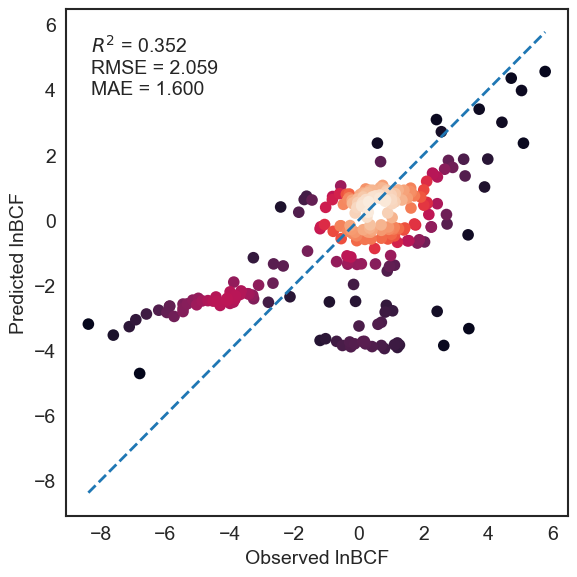

In [ ]:
density_scatter(y_wheat, pred_wheat, save_path="../../Fig/field_wheat.pdf")
density_scatter(y_maize, pred_maize, save_path="../../Fig/field_maize.pdf")

In [28]:
# ==========================================================
# Build calibration features
# ==========================================================

def build_calib_features(
    X,
    base_pred
):

    Xc = pd.DataFrame(index=X.index)

    # CatBoost原始预测
    Xc["base_pred"] = base_pred

    # 连续校准变量
    extra_cols = [
        "logSRC",
        "logED",
        "pH",
        "SOC",
        "CEC",
        "Clay"
    ]

    for c in extra_cols:
        if c in X.columns:
            Xc[c] = X[c]

    # Tissue编码
    if "Tissue" in X.columns:
        Xc["Tissue"] = X["Tissue"]

        Xc = pd.get_dummies(
            Xc,
            columns=["Tissue"]
        )

    return Xc

In [29]:
# ==========================================================
# Stratified bins
# ==========================================================

def make_bins(X, y, n_bins=5):

    y = pd.Series(y).reset_index(drop=True)

    bins = pd.qcut(
        y,
        q=min(n_bins, y.nunique()),
        duplicates="drop"
    ).astype(str)

    tissue = X["Tissue"].astype(str).reset_index(drop=True)

    strata = tissue + "_" + bins

    return strata

In [ ]:
# ==========================================================
# Few-shot adaptation
# ==========================================================

def run_fewshot(
    X,
    y,
    keep_df,
    name,
    shots=[0,5,10,20,30,40,50],
    n_repeat=100,
    alpha=1.0,
    save_shots=[10,20,50]   # 想保存散点图的shot
):
    saved_models = {}
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)

    base_pred = model.predict(X)

    Xc = build_calib_features(X, base_pred)

    results = []

    saved_examples = {}

    saved_tables = {}

    # ======================================================
    # 0-shot
    # ======================================================

    m0 = evaluate(y, base_pred)

    results.append({
        "Dataset": name,
        "shot": 0,
        "Median_R2": m0["R2"],
        "R2_low": m0["R2"],
        "R2_high": m0["R2"],
        "Gain_R2": 0,
        "Median_RMSE": m0["RMSE"],
        "Median_MAE": m0["MAE"],
        "Positive_R2_pct": 100 if m0["R2"] > 0 else 0
    })

    saved_examples[0] = {
        "true": y.copy(),
        "pred": base_pred.copy()
    }
    table0 = X.copy()
    table0["Observed_lnBCF"] = y.values
    table0["Pred_before"] = base_pred
    table0["Pred_after"] = base_pred

    saved_tables[0] = table0

    strata = make_bins(
        X,
        y
    )

    # ======================================================
    # Few-shot
    # ======================================================

    for shot in shots:

        if shot == 0:
            continue

        shot = min(shot, len(y)-10)

        if shot < 2:
            continue

        r2s = []
        rmses = []
        maes = []

        all_true = []
        all_pred = []

        for rep in range(n_repeat):
            ############################################################
            # Step 1：every tissue at least one sample
            ############################################################

            rng = np.random.RandomState(42 + rep)

            calib_idx = []

            for tissue in X["Tissue"].unique():

                tissue_idx = X.index[
                    X["Tissue"] == tissue
                ].tolist()

                calib_idx.append(
                    rng.choice(tissue_idx)
                )

            ############################################################
            # Step 2：select remaining samples stratified
            ############################################################

            remain = shot - len(calib_idx)

            remain_pool = np.setdiff1d(
                np.arange(len(X)),
                calib_idx
            )

            if remain > 0:

                remain_strata = strata.iloc[remain_pool]

                splitter = StratifiedShuffleSplit(
                    n_splits=1,
                    train_size=remain,
                    random_state=42 + rep
                )

                try:

                    add_idx, _ = next(

                        splitter.split(
                            remain_pool,
                            remain_strata
                        )

                    )

                    calib_idx.extend(
                        remain_pool[add_idx]
                    )

                except:

                    calib_idx.extend(

                        rng.choice(
                            remain_pool,
                            remain,
                            replace=False
                        )

                    )

            calib_idx = np.array(calib_idx)

            test_idx = np.setdiff1d(
                np.arange(len(X)),
                calib_idx
            )

            if len(test_idx) < max(10, int(0.3 * len(y))):
                continue

            reg = Ridge(alpha=alpha)

            reg.fit(
                Xc.iloc[calib_idx],
                y.iloc[calib_idx]
            )

            pred = reg.predict(
                Xc.iloc[test_idx]
            )

            true = y.iloc[test_idx]

            mm = evaluate(true, pred)

            r2s.append(mm["R2"])
            rmses.append(mm["RMSE"])
            maes.append(mm["MAE"])

            all_true.append(true)
            all_pred.append(pred)

        median_r2 = np.median(r2s)

        results.append({

            "Dataset": name,
            "shot": shot,

            "Median_R2": median_r2,

            "R2_low": np.percentile(r2s, 2.5),
            "R2_high": np.percentile(r2s, 97.5),

            "Gain_R2": median_r2 - m0["R2"],

            "Median_RMSE": np.median(rmses),
            "Median_MAE": np.median(maes),

            "Positive_R2_pct":
                np.mean(np.array(r2s) > 0) * 100
        })

        # ==================================================
        # save the best model and examples for the current shot
        # ==================================================

        if shot in save_shots:

            best_rep = np.argmin(
                np.abs(np.array(r2s) - median_r2)
            )

            # 重新生成对应的划分
            splitter = StratifiedShuffleSplit(
                n_splits=1,
                train_size=shot,
                random_state=42 + best_rep
            )

            try:
                calib_idx, test_idx = next(
                    splitter.split(Xc, strata)
                )
            except:
                idx = np.arange(len(y))
                np.random.seed(42 + best_rep)
                calib_idx = np.random.choice(
                    idx,
                    shot,
                    replace=False
                )

            # 重新训练
            best_reg = Ridge(alpha=alpha)

            best_reg.fit(
                Xc.iloc[calib_idx],
                y.iloc[calib_idx]
            )

            saved_models[shot] = best_reg

            #
            saved_examples[shot] = {

            "true": all_true[best_rep],

            "pred": all_pred[best_rep]
        }

        best_table = X.iloc[test_idx].copy()
        
        best_table["Longitude"] = keep_df.iloc[test_idx]["Longitude"].values
        best_table["Latitude"] = keep_df.iloc[test_idx]["Latitude"].values
        best_table["PFAS"] = keep_df.iloc[test_idx]["PFAS"].values

        best_table["Observed_lnBCF"] = y.iloc[test_idx].values

        best_table["Pred_before"] = base_pred[test_idx]

        best_table["Pred_after"] = pred

        saved_tables[shot] = best_table.reset_index(drop=True)

    return (
        pd.DataFrame(results), 
        saved_examples, 
        saved_tables, 
        saved_models
    )

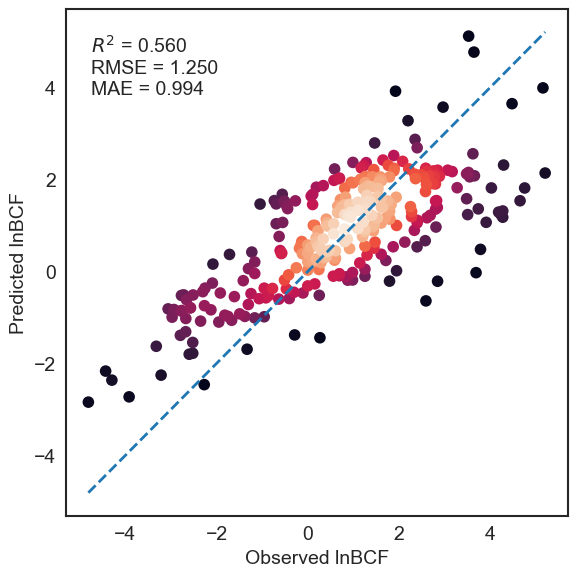

In [ ]:
few_wheat, wheat_examples, wheat_tables, wheat_models = run_fewshot(
    X_wheat,
    y_wheat,
    wheat_keep,
    "wheat"
)
density_scatter(
    wheat_examples[50]["true"],
    wheat_examples[50]["pred"],
    save_path="../../Fig/50shot.pdf"
)

In [37]:
import joblib
for shot, ridge_model in wheat_models.items():

    joblib.dump(
        ridge_model,
        f"wheat_fewshot_ridge_{shot}.pkl"
    )

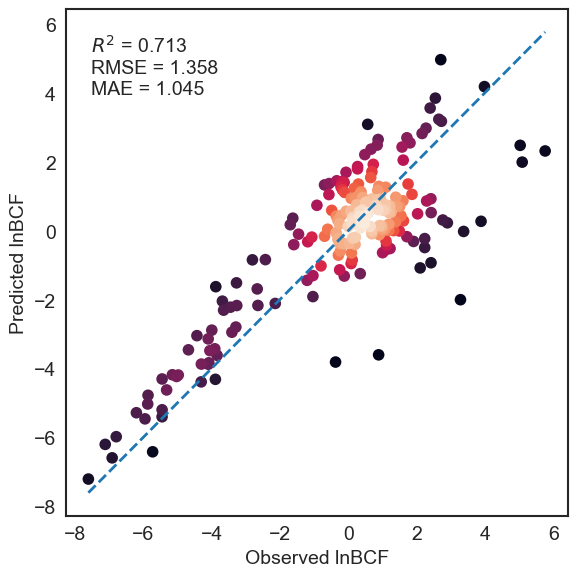

In [ ]:
few_maize, maize_examples, maize_tables, maize_models = run_fewshot(
    X_maize,
    y_maize,
    maize_keep,
    "maize"
)
for shot, ridge_model in maize_models.items():

    joblib.dump(
        ridge_model,
        f"maize_fewshot_ridge_{shot}.pkl"
    )
density_scatter(
    maize_examples[50]["true"],
    maize_examples[50]["pred"],
    save_path="../../Fig/50shot-maize.pdf"
)

In [39]:
fewshot_df = pd.concat(
    [few_wheat, few_maize],
    ignore_index=True
)

print("\n=== Few-shot Results ===")
print(fewshot_df)


=== Few-shot Results ===
   Dataset  shot  Median_R2    R2_low   R2_high   Gain_R2  Median_RMSE  \
0    wheat     0  -0.449565 -0.449565 -0.449565  0.000000     2.262875   
1    wheat     5   0.173397 -1.113940  0.538630  0.622962     1.706299   
2    wheat    10   0.400466 -0.271373  0.570004  0.850031     1.458767   
3    wheat    20   0.521749  0.084871  0.578170  0.971314     1.300585   
4    wheat    30   0.537730  0.432181  0.594002  0.987295     1.276425   
5    wheat    40   0.552205  0.439318  0.593336  1.001770     1.256495   
6    wheat    50   0.560263  0.473102  0.598790  1.009828     1.249196   
7    maize     0   0.352434  0.352434  0.352434  0.000000     2.059241   
8    maize     5   0.262574 -1.033230  0.644881 -0.089859     2.196474   
9    maize    10   0.574140 -0.174825  0.703267  0.221706     1.672941   
10   maize    20   0.687548  0.483757  0.724573  0.335114     1.434010   
11   maize    30   0.702614  0.568970  0.737895  0.350180     1.406934   
12   maize  

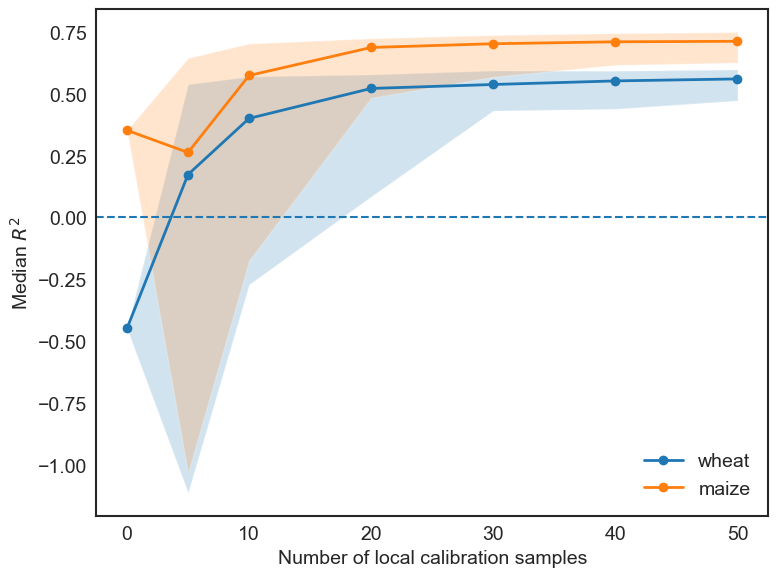

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

for ds in fewshot_df["Dataset"].unique():

    sub = fewshot_df[
        fewshot_df["Dataset"] == ds
    ]

    ax.plot(
        sub["shot"],
        sub["Median_R2"],
        marker='o',
        linewidth=2,
        label=ds
    )

    ax.fill_between(
        sub["shot"],
        sub["R2_low"],
        sub["R2_high"],
        alpha=0.2
    )

ax.axhline(
    0,
    linestyle='--',
    linewidth=1.5
)

ax.set_xlabel(
    "Number of local calibration samples"
)

ax.set_ylabel(
    "Median $R^2$"
)

# ax.set_title(
#     "Few-shot Field Adaptation"
# )

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    "../../Fig/fewshot_adaptation.pdf",
    dpi=600,
    bbox_inches='tight'
)
plt.show()

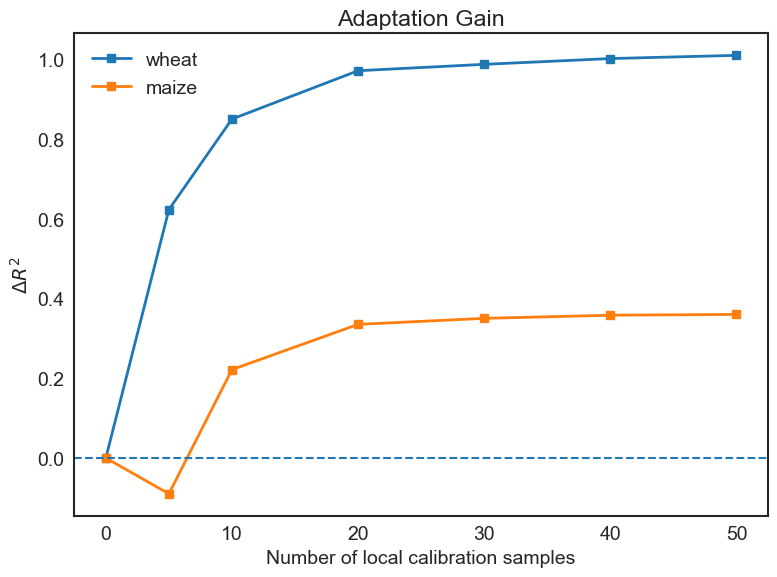

In [ ]:
# ==========================================================
# Adaptation gain plot
# ==========================================================

fig, ax = plt.subplots(figsize=(8,6))

for ds in fewshot_df["Dataset"].unique():

    sub = fewshot_df[
        fewshot_df["Dataset"] == ds
    ]

    ax.plot(
        sub["shot"],
        sub["Gain_R2"],
        marker='s',
        linewidth=2,
        label=ds
    )

ax.axhline(
    0,
    linestyle='--'
)

ax.set_xlabel(
    "Number of local calibration samples"
)

ax.set_ylabel(
    "$\\Delta R^2$"
)

ax.set_title(
    "Adaptation Gain"
)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    "../../Fig/adaptation_gain.pdf",
    dpi=600,
    bbox_inches='tight'
)
plt.show()

In [27]:
for shot in [10,20,50]:

    maize_tables[shot].to_excel(
        f"../../dataset/nature data/maize_{shot}shot_prediction.xlsx",
        index=False
    )

    wheat_tables[shot].to_excel(
        f"../../dataset/nature data/wheat_{shot}shot_prediction.xlsx",
        index=False
    )